In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = Ridge(alpha=1.0, random_state=42)

In [22]:
model.fit(X_train_scaled, y_train)

Ridge(random_state=42)

In [23]:
predictions = model.predict(X_test_scaled)

In [24]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [25]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f} (1.0 is a perfect prediction)\n")

Mean Squared Error: 2892.01
R-squared Score: 0.4541 (1.0 is a perfect prediction)



In [26]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

In [27]:
plt.scatter(y_test, predictions, color='#2c7bb6', alpha=0.7, edgecolors='k')

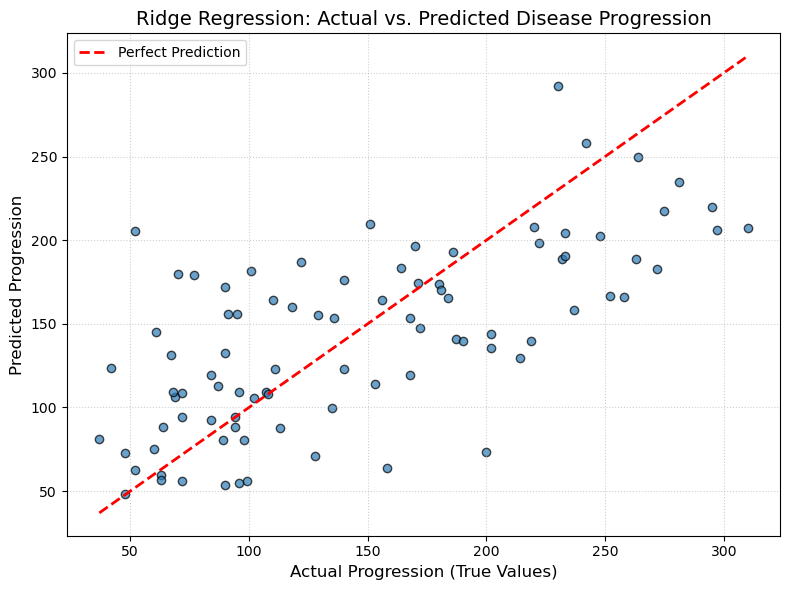

In [28]:
min_val = min(np.min(y_test), np.min(predictions))
max_val = max(np.max(y_test), np.max(predictions))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label="Perfect Prediction")

plt.title("Ridge Regression: Actual vs. Predicted Disease Progression", fontsize=14)
plt.xlabel("Actual Progression (True Values)", fontsize=12)
plt.ylabel("Predicted Progression", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()